In [2]:
#Sowing Success: How Machine Learning Helps Farmers Select the Best Crops
#![Farmer in a field](https://www.utthancareerinstitute.com/wp-content/uploads/2023/02/What-Is-Crop-In-Agriculture.jpg)
#Measuring essential soil metrics such as nitrogen, phosphorous, potassium levels, and pH value is an important aspect of assessing soil condition. However,
#it can be an expensive and time-consuming process, which can cause farmers to prioritize which metrics to measure based on their budget constraints.
#Farmers have various options when it comes to deciding which crop to plant each season. Their primary objective is to maximize the yield of their crops,
#taking into account different factors. One crucial factor that affects crop growth is the condition of the soil in the field, which can be assessed by
#measuring basic element such as nitrogen and potassium levels. Each crop has an ideal soil condition that ensures optimal growth and maximum yield.
#A farmer reached out to you as a machine learning expert for assistance in selecting the best crop for his field. They've provided you with a dataset called `soil_measures.csv`, which contains:
#- `"N"`: Nitrogen content ratio in the soil
#- `"P"`: Phosphorous content ratio in the soil
#- `"K"`: Potassium content ratio in the soil
#- `"pH"` value of the soil
#- `"crop"`: categorical values that contain various crops (target variable).
#Each row in this dataset represents various measures of the soil in a particular field.
#Based on these measurements, the crop specified in the `"crop"` column is the optimal choice for that field.  
#In this project, you will apply machine learning to build a multi-class classification model to predict the type of 
#`"crop"`, while using techniques to avoid multicollinearity, which is a concept where two or more features are highly correlated.

In [3]:
# All required libraries are imported here for you.
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings("ignore")
# Load the dataset
crops = pd.read_csv(r"C:\Users\KIIT\Downloads\soil_measures (1).csv")

In [4]:
crops.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


In [5]:
crops.shape

(2200, 5)

In [6]:
crops.crop.value_counts()

crop
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [7]:
crops.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


In [8]:
crops.describe()

,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091


In [9]:
# Splitting the data
features = ["N", "P", "K", "ph"]

X_train, X_test, y_train, y_test = train_test_split(crops[features], crops.crop, test_size=0.2, random_state=42)

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

# Load dataset (update path or use pd.read_csv('soil_measures.csv'))
crops = pd.read_csv(r"C:\Users\KIIT\Downloads\soil_measures (1).csv")

print("Dataset shape:", crops.shape)
print("\nFirst 5 rows:")
print(crops.head())
print("\nUnique crops:", crops['crop'].nunique())

# Features and target
X = crops[['N', 'P', 'K', 'ph']]
y = crops['crop']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=12, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X.columns, 
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X.columns, 
    index=X_test.index
)

# Store performance
model_performance = {}

for feature in ['N', 'P', 'K', 'ph']:
    log_reg = LogisticRegression(
        max_iter=5000,
        multi_class='multinomial',
        random_state=12
    )
    
    # Train on single feature
    log_reg.fit(X_train_scaled[[feature]], y_train)
    
    # Predict
    y_pred = log_reg.predict(X_test_scaled[[feature]])
    
    # Weighted F1-score (good for multi-class)
    score = f1_score(y_test, y_pred, average='weighted')
    model_performance[feature] = round(score, 4)
    
    print(f"F1-score for {feature}: {score:.4f}")

print("\nModel Performance:", model_performance)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(model_performance.keys(), model_performance.values(), color=['skyblue', 'lightgreen', 'salmon', 'gold'])
plt.xlabel("Features")
plt.ylabel("Weighted F1-Score")
plt.title("Single Feature Performance for Crop Prediction")
plt.ylim(0, 1)
for i, v in enumerate(model_performance.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.show()

Dataset shape: (2200, 5)

First 5 rows:
    N   P   K        ph  crop
0  90  42  43  6.502985  rice
1  85  58  41  7.038096  rice
2  60  55  44  7.840207  rice
3  74  35  40  6.980401  rice
4  78  42  42  7.628473  rice

Unique crops: 22


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

F1-score for N: 0.1293
F1-score for P: 0.1647
F1-score for K: 0.2160
F1-score for ph: 0.0714

Final Model Performance:
{'N': 0.1293, 'P': 0.1647, 'K': 0.216, 'ph': 0.0714}


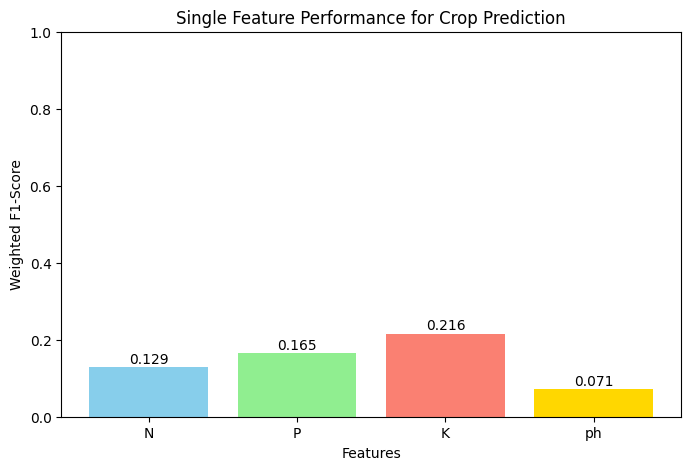

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

# Load the dataset
crops = pd.read_csv(r"C:\Users\KIIT\Downloads\soil_measures (1).csv")

# Features and target
X = crops[['N', 'P', 'K', 'ph']]
y = crops['crop']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=12, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), 
                              columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), 
                             columns=X.columns, index=X_test.index)

# Dictionary to store scores
model_performance = {}

for feature in ['N', 'P', 'K', 'ph']:
    # Create model - Removed multi_class parameter
    log_reg = LogisticRegression(
        max_iter=5000,
        random_state=12
    )
    
    # Train on single feature
    log_reg.fit(X_train_scaled[[feature]], y_train)
    
    # Predict
    y_pred = log_reg.predict(X_test_scaled[[feature]])
    
    # Calculate weighted F1 score
    score = f1_score(y_test, y_pred, average='weighted')
    model_performance[feature] = round(score, 4)
    
    print(f"F1-score for {feature}: {score:.4f}")

print("\nFinal Model Performance:")
print(model_performance)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(model_performance.keys(), model_performance.values(), 
               color=['skyblue', 'lightgreen', 'salmon', 'gold'])
plt.xlabel("Features")
plt.ylabel("Weighted F1-Score")
plt.title("Single Feature Performance for Crop Prediction")
plt.ylim(0, 1)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, 
             f'{height:.3f}', ha='center')

plt.show()

In [18]:
# Estimating feature correlation 
correlations = crops[features].corr()
correlations

,N,P,K,ph
N,1.000000,-0.231460,-0.140512,0.096683
P,-0.231460,1.000000,0.736232,-0.138019
K,-0.140512,0.736232,1.000000,-0.169503
ph,0.096683,-0.138019,-0.169503,1.000000


<Axes: >

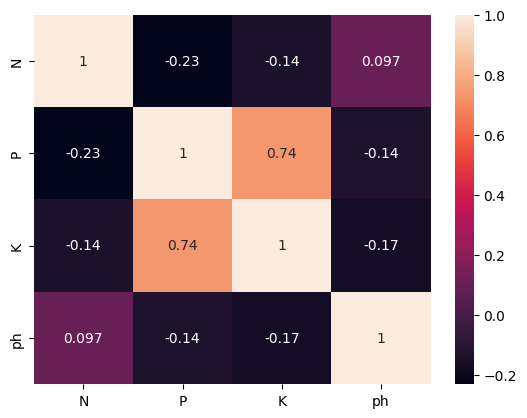

In [19]:
sns.heatmap(correlations, annot=True)

In [22]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

# Load dataset
crops = pd.read_csv(r"C:\Users\KIIT\Downloads\soil_measures (1).csv")

# Best final features (good performance + low correlation)
final_features = ['K', 'N', 'ph']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    crops[final_features], 
    crops["crop"], 
    test_size=0.2, 
    random_state=42,
    stratify=crops["crop"]
)

# Scale the features (very important!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Final Model
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

# Performance
model_performance = f1_score(y_test, y_pred, average="weighted")
print(f"Final Model Weighted F1-Score: {model_performance:.4f}")

Final Model Weighted F1-Score: 0.4998
